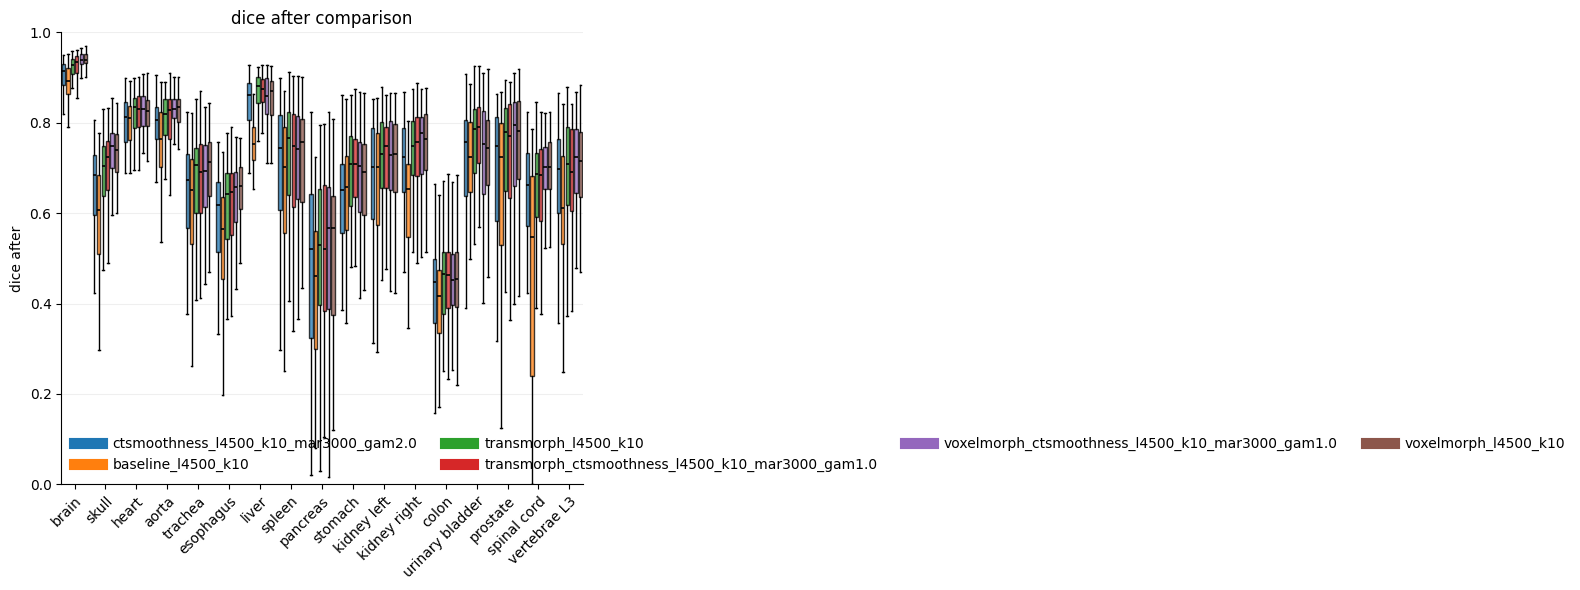

In [1]:
import ast
import os

import matplotlib.pyplot as plt
import numpy as np


DEFAULT_ORGANS = [
    "brain",
    "skull",
    "heart",
    "aorta",
    "trachea",
    "esophagus",
    "liver",
    "spleen",
    "pancreas",
    "stomach",
    "kidney_left",
    "kidney_right",
    "colon",
    "urinary_bladder",
    "prostate",
    "spinal_cord",
    "vertebrae_L3",
]

TXT_FILES = [
    "/share/home/xcwu/pet_reg_results/ctsmoothness_l4500_k10_mar3000_gam2.0.txt",
    "/share/home/xcwu/pet_reg_results/baseline_l4500_k10.txt",
    "/share/home/xcwu/pet_reg_results/transmorph_l4500_k10.txt",
    "/share/home/xcwu/pet_reg_results/transmorph_ctsmoothness_l4500_k10_mar3000_gam1.0.txt",
    # "/share/home/xcwu/pet_reg_results/svr_diff_l4500_k10_mar3000_beta1_a1.1_b1_repo_logbeta.txt",
    "/share/home/xcwu/pet_reg_results/voxelmorph_ctsmoothness_l4500_k10_mar3000_gam1.0.txt",
    "/share/home/xcwu/pet_reg_results/voxelmorph_l4500_k10.txt",
    
]

LABELS = None
METRIC = "dice_after"
ORGANS = DEFAULT_ORGANS
USE_HORIZONTAL = False
SHOW_FLIERS = False
TITLE = None
OUTPUT = None


def parse_list_line(line):
    values = []
    for part in line.strip().split(";"):
        part = part.strip()
        try:
            values.append(ast.literal_eval(part))
        except Exception:
            values.append(part)
    return values


def load_registration_results(filename):
    """
    Load one registration result txt produced by Registration/inferencing.py.

    Returns:
        dict with masks_names, dice_before, dice_after, tre_before, tre_after.
    """
    with open(filename, "r") as f:
        lines = f.readlines()

    if len(lines) < 5:
        raise ValueError(
            f"{filename} should contain at least 5 lines: masks, dice before, "
            "dice after, TRE before, TRE after."
        )

    return {
        "masks_names": parse_list_line(lines[0]),
        "dice_before": parse_list_line(lines[1]),
        "dice_after": parse_list_line(lines[2]),
        "tre_before": parse_list_line(lines[3]),
        "tre_after": parse_list_line(lines[4]),
    }


def get_metrics_for_masks(
    mask_names_input,
    masks_names,
    dice_before_lists,
    dice_after_lists,
    tre_before_lists,
    tre_after_lists,
):
    results = {}
    for name in mask_names_input:
        if name in masks_names:
            idx = masks_names.index(name)
            results[name] = {
                "dice_before": dice_before_lists[idx],
                "dice_after": dice_after_lists[idx],
                "tre_before": tre_before_lists[idx],
                "tre_after": tre_after_lists[idx],
            }
        else:
            results[name] = {
                "dice_before": None,
                "dice_after": None,
                "tre_before": None,
                "tre_after": None,
            }
    return results


def default_label_from_path(path):
    return os.path.splitext(os.path.basename(path))[0]


def common_organs(results):
    common = set(results[0]["masks_names"])
    for result in results[1:]:
        common &= set(result["masks_names"])

    return [organ for organ in results[0]["masks_names"] if organ in common]


def choose_organs(results, organs, use_default_organs):
    available = common_organs(results)
    if organs:
        missing = [organ for organ in organs if organ not in available]
        if missing:
            raise ValueError(
                "These organs are missing from at least one txt file: "
                + ", ".join(missing)
            )
        return organs

    if use_default_organs:
        selected = [organ for organ in DEFAULT_ORGANS if organ in available]
        if selected:
            return selected

    return available


def collect_metric_data(results, metric, selected_organs):
    all_data = []
    for result in results:
        masks_names = result["masks_names"]
        metric_lists = result[metric]
        data_for_file = []

        for organ in selected_organs:
            organ_index = masks_names.index(organ)
            data_for_file.append(np.asarray(metric_lists[organ_index], dtype=float))

        all_data.append(data_for_file)

    return all_data


def make_colors(num_items):
    cmap = plt.get_cmap("tab10")
    return [cmap(i % 10) for i in range(num_items)]


def plot_metric_boxplot(
    results,
    labels,
    selected_organs,
    metric="dice_after",
    title=None,
    orientation="vertical",
    show_fliers=False,
):
    """
    Plot grouped boxplots. Each txt file becomes one boxplot series.
    """
    metric_data = collect_metric_data(results, metric, selected_organs)
    num_organs = len(selected_organs)
    num_files = len(results)

    if num_organs == 0:
        raise ValueError("No organs selected for plotting.")

    colors = make_colors(num_files)
    group_spacing = num_files + 1
    positions_base = np.arange(num_organs) * group_spacing
    box_width = 0.75

    if orientation == "horizontal":
        fig, ax = plt.subplots(figsize=(9, max(5, num_organs * 0.45)))
    else:
        fig, ax = plt.subplots(figsize=(max(10, num_organs * 0.7), 6))

    for file_index, (data_for_file, label) in enumerate(zip(metric_data, labels)):
        offset = file_index - (num_files - 1) / 2
        positions = positions_base + offset

        boxplot_kwargs = {
            "positions": positions,
            "widths": box_width,
            "patch_artist": True,
            "showfliers": show_fliers,
            "flierprops": {
                "marker": "o",
                "markersize": 3,
                "linestyle": "none",
                "markerfacecolor": "black",
                "alpha": 0.45,
            },
        }
        if orientation == "horizontal":
            boxplot_kwargs["vert"] = False

        bp = ax.boxplot(data_for_file, **boxplot_kwargs)
        for patch in bp["boxes"]:
            patch.set_facecolor(colors[file_index])
            patch.set_alpha(0.75)
        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.2)

        ax.plot([], [], color=colors[file_index], linewidth=8, label=label)

    clean_organs = [organ.replace("_", " ") for organ in selected_organs]
    if orientation == "horizontal":
        ax.set_yticks(positions_base)
        ax.set_yticklabels(clean_organs)
        ax.set_xlabel(metric.replace("_", " "))
        if metric.startswith("dice"):
            ax.set_xlim(0, 1)
    else:
        ax.set_xticks(positions_base)
        ax.set_xticklabels(
            clean_organs,
            rotation=45,
            ha="right",
            rotation_mode="anchor",
        )
        ax.set_ylabel(metric.replace("_", " "))
        if metric.startswith("dice"):
            ax.set_ylim(0, 1)

    if title:
        ax.set_title(title)

    ax.legend(ncol=min(num_files, 4), frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x" if orientation == "horizontal" else "y", alpha=0.2)

    fig.tight_layout()
    return fig, ax


def plot_boxplots_from_txt_files(
    txt_files,
    labels=None,
    metric="dice_after",
    organs=None,
    use_horizontal=False,
    show_fliers=False,
    title=None,
    output=None,
):
    results = [load_registration_results(path) for path in txt_files]

    if labels is None:
        labels = [default_label_from_path(path) for path in txt_files]
    if len(labels) != len(txt_files):
        raise ValueError("labels must have the same length as txt_files.")

    selected_organs = choose_organs(
        results,
        organs=organs,
        use_default_organs=False,
    )

    if title is None:
        title = f"{metric.replace('_', ' ')} comparison"

    fig, _ = plot_metric_boxplot(
        results,
        labels,
        selected_organs,
        metric=metric,
        title=title,
        orientation="horizontal" if use_horizontal else "vertical",
        show_fliers=show_fliers,
    )

    if output:
        fig.savefig(output, dpi=300, bbox_inches="tight")
        print(f"Saved figure to {output}")

    plt.show()
    return fig


def main():
    if not TXT_FILES:
        raise ValueError("Please fill TXT_FILES with one or more result txt paths.")

    plot_boxplots_from_txt_files(
        TXT_FILES,
        labels=LABELS,
        metric=METRIC,
        organs=ORGANS,
        use_horizontal=USE_HORIZONTAL,
        show_fliers=SHOW_FLIERS,
        title=TITLE,
        output=OUTPUT,
    )


if __name__ == "__main__":
    main()


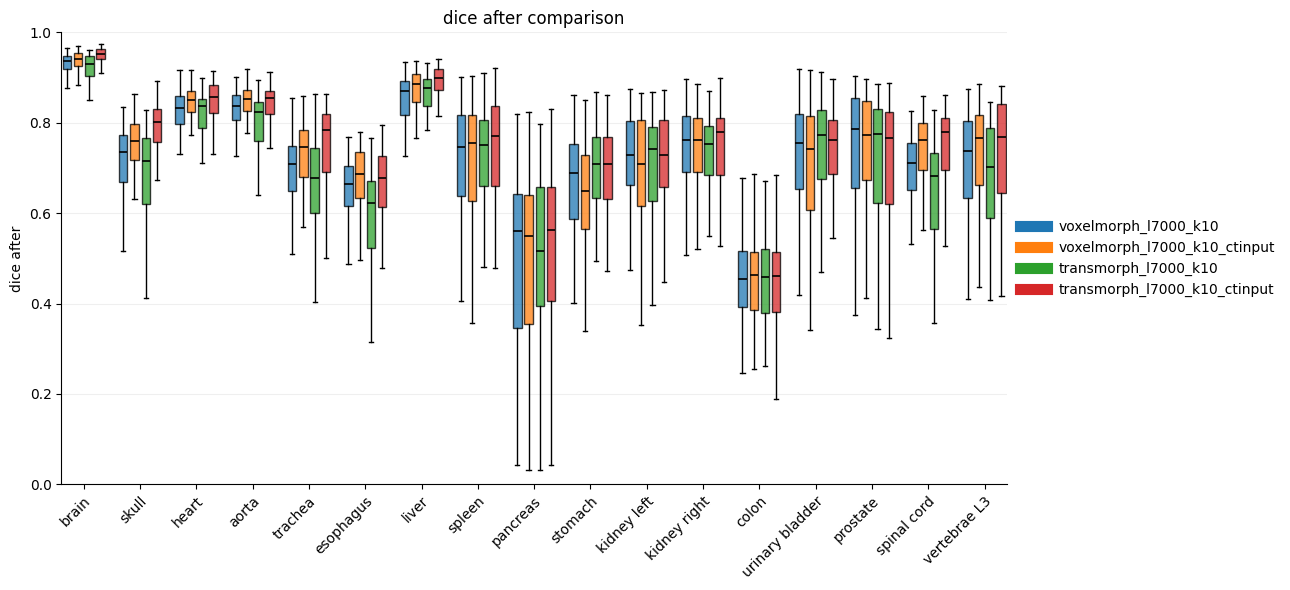

In [13]:

import ast
import os

import matplotlib.pyplot as plt
import numpy as np

DEFAULT_ORGANS = [
    "brain",
    "skull",
    "heart",
    "aorta",
    "trachea",
    "esophagus",
    "liver",
    "spleen",
    "pancreas",
    "stomach",
    "kidney_left",
    "kidney_right",
    "colon",
    "urinary_bladder",
    "prostate",
    "spinal_cord",
    "vertebrae_L3",
]

TXT_FILES = [
    # "voxelmorph_l7000_k10.txt",
    "/share/home/xcwu/pet_reg_results/voxelmorph_l7000_k10.txt",
    "/share/home/xcwu/pet_reg_results/voxelmorph_l7000_k10_ctinput.txt",
    # "/share/home/xcwu/pet_reg_results/voxelmorph_ctsmoothness_l7000_k10_mar3000_gam2.0.txt",
    "/share/home/xcwu/pet_reg_results/transmorph_l7000_k10.txt",
    "/share/home/xcwu/pet_reg_results/transmorph_l7000_k10_ctinput.txt",
    # "/share/home/xcwu/pet_reg_results/transmorph_ctsmoothness_l7000_k10_mar3000_gam2.0.txt",
    # "/share/home/xcwu/pet_reg_results/ants_fdgct_to_psmact.txt"
]

LABELS = None
METRIC = "dice_after"
ORGANS = DEFAULT_ORGANS
USE_HORIZONTAL = False
SHOW_FLIERS = False
TITLE = None
OUTPUT = None

def parse_list_line(line):
    values = []
    for part in line.strip().split(";"):
        part = part.strip()
        try:
            values.append(ast.literal_eval(part))
        except Exception:
            values.append(part)
    return values

def load_registration_results(filename):
    """
    Load one registration result txt produced by Registration/inferencing.py.

    Returns:
        dict with masks_names, dice_before, dice_after, tre_before, tre_after.
    """
    with open(filename, "r") as f:
        lines = f.readlines()

    if len(lines) < 5:
        raise ValueError(
            f"{filename} should contain at least 5 lines: masks, dice before, "
            "dice after, TRE before, TRE after."
        )

    return {
        "masks_names": parse_list_line(lines[0]),
        "dice_before": parse_list_line(lines[1]),
        "dice_after": parse_list_line(lines[2]),
        "tre_before": parse_list_line(lines[3]),
        "tre_after": parse_list_line(lines[4]),
    }

def common_organs(results):
    common = set(results[0]["masks_names"])
    for result in results[1:]:
        common &= set(result["masks_names"])

    return [organ for organ in results[0]["masks_names"] if organ in common]

def choose_organs(results, organs, use_default_organs):
    available = common_organs(results)
    if organs:
        missing = [organ for organ in organs if organ not in available]
        if missing:
            raise ValueError(
                "These organs are missing from at least one txt file: "
                ", ".join(missing)
            )
        return organs

    if use_default_organs:
        selected = [organ for organ in DEFAULT_ORGANS if organ in available]
        if selected:
            return selected

    return available

def collect_metric_data(results, metric, selected_organs):
    all_data = []
    for result in results:
        masks_names = result["masks_names"]
        metric_lists = result[metric]
        data_for_file = []

        for organ in selected_organs:
            organ_index = masks_names.index(organ)
            data_for_file.append(np.asarray(metric_lists[organ_index], dtype=float))

        all_data.append(data_for_file)

    return all_data

def make_colors(num_items):
    cmap = plt.get_cmap("tab10")
    return [cmap(i % 10) for i in range(num_items)]

def plot_metric_boxplot(
    results,
    labels,
    selected_organs,
    metric="dice_after",
    title=None,
    orientation="vertical",
    show_fliers=False,
):
    """
    Plot grouped boxplots. Each txt file becomes one boxplot series.
    """
    metric_data = collect_metric_data(results, metric, selected_organs)
    num_organs = len(selected_organs)
    num_files = len(results)

    if num_organs == 0:
        raise ValueError("No organs selected for plotting.")

    colors = make_colors(num_files)
    group_spacing = num_files + 1
    positions_base = np.arange(num_organs) * group_spacing
    box_width = 0.75

    # 1. 调整画布大小，如果是垂直布局，增加宽度以容纳右侧图例
    if orientation == "horizontal":
        fig, ax = plt.subplots(figsize=(9, max(5, num_organs * 0.45)))
    else:
        # 增加宽度 (例如 12 或更多)，防止图例遮挡图形
        fig, ax = plt.subplots(figsize=(max(14, num_organs * 0.9), 6))

    for file_index, (data_for_file, label) in enumerate(zip(metric_data, labels)):
        offset = file_index - (num_files - 1) / 2
        positions = positions_base + offset

        boxplot_kwargs = {
            "positions": positions,
            "widths": box_width,
            "patch_artist": True,
            "showfliers": show_fliers,
            "flierprops": {
                "marker": "o",
                "markersize": 3,
                "linestyle": "none",
                "markerfacecolor": "black",
                "alpha": 0.45,
            },
        }
        if orientation == "horizontal":
            boxplot_kwargs["vert"] = False

        bp = ax.boxplot(data_for_file, **boxplot_kwargs)
        for patch in bp["boxes"]:
            patch.set_facecolor(colors[file_index])
            patch.set_alpha(0.75)
        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.2)

        # 用于图例的空线条
        ax.plot([], [], color=colors[file_index], linewidth=8, label=label)

    clean_organs = [organ.replace("_", " ") for organ in selected_organs]
    if orientation == "horizontal":
        ax.set_yticks(positions_base)
        ax.set_yticklabels(clean_organs)
        ax.set_xlabel(metric.replace("_", " "))
        if metric.startswith("dice"):
            ax.set_xlim(0, 1)
    else:
        ax.set_xticks(positions_base)
        ax.set_xticklabels(
            clean_organs,
            rotation=45,
            ha="right",
            rotation_mode="anchor",
        )
        ax.set_ylabel(metric.replace("_", " "))
        if metric.startswith("dice"):
            ax.set_ylim(0, 1)

    if title:
        ax.set_title(title)

    # 2. 将图例放置在图表右侧外部
    # ncol=1 使得图例垂直排列，更易阅读
    # bbox_to_anchor=(1, 0.5) 将图例锚定在 axes 的右侧中心
    ax.legend(
        ncol=1,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        fontsize="medium",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x" if orientation == "horizontal" else "y", alpha=0.2)

    # 3. 调整布局以保留图例空间
    # rect 参数留出右侧空间 (左, 下, 右, 上)
    fig.tight_layout(rect=[0, 0, 0.85, 1])
    return fig, ax

def default_label_from_path(path):
    return os.path.splitext(os.path.basename(path))[0]

def plot_boxplots_from_txt_files(
    txt_files,
    labels=None,
    metric="dice_after",
    organs=None,
    use_horizontal=False,
    show_fliers=False,
    title=None,
    output=None,
):
    results = [load_registration_results(path) for path in txt_files]

    if labels is None:
        labels = [default_label_from_path(path) for path in txt_files]
    if len(labels) != len(txt_files):
        raise ValueError("labels must have the same length as txt_files.")

    selected_organs = choose_organs(
        results,
        organs=organs,
        use_default_organs=False,
    )

    if title is None:
        title = f"{metric.replace('_', ' ')} comparison"

    fig, _ = plot_metric_boxplot(
        results,
        labels,
        selected_organs,
        metric=metric,
        title=title,
        orientation="horizontal" if use_horizontal else "vertical",
        show_fliers=show_fliers,
    )

    if output:
        fig.savefig(output, dpi=300, bbox_inches="tight")
        print(f"Saved figure to {output}")

    plt.show()
    return fig

def main():
    if not TXT_FILES:
        raise ValueError("Please fill TXT_FILES with one or more result txt paths.")

    plot_boxplots_from_txt_files(
        TXT_FILES,
        labels=LABELS,
        metric=METRIC,
        organs=ORGANS,
        use_horizontal=USE_HORIZONTAL,
        show_fliers=SHOW_FLIERS,
        title=TITLE,
        output=OUTPUT,
    )

if __name__ == "__main__":
    main()

Average over selected organs (mean per organ first, then mean over organs):

dice after:
  voxelmorph_l4500_k10: 0.7092
  voxelmorph_ctsmoothness_l4500_k10_mar3000_gam2.0: 0.7154
  transmorph_l4500_k10: 0.6967
  transmorph_ctsmoothness_l4500_k10_mar3000_gam2.0: 0.6970

tre after:
  voxelmorph_l4500_k10: 5.5620
  voxelmorph_ctsmoothness_l4500_k10_mar3000_gam2.0: 5.6035
  transmorph_l4500_k10: 5.9243
  transmorph_ctsmoothness_l4500_k10_mar3000_gam2.0: 6.0151


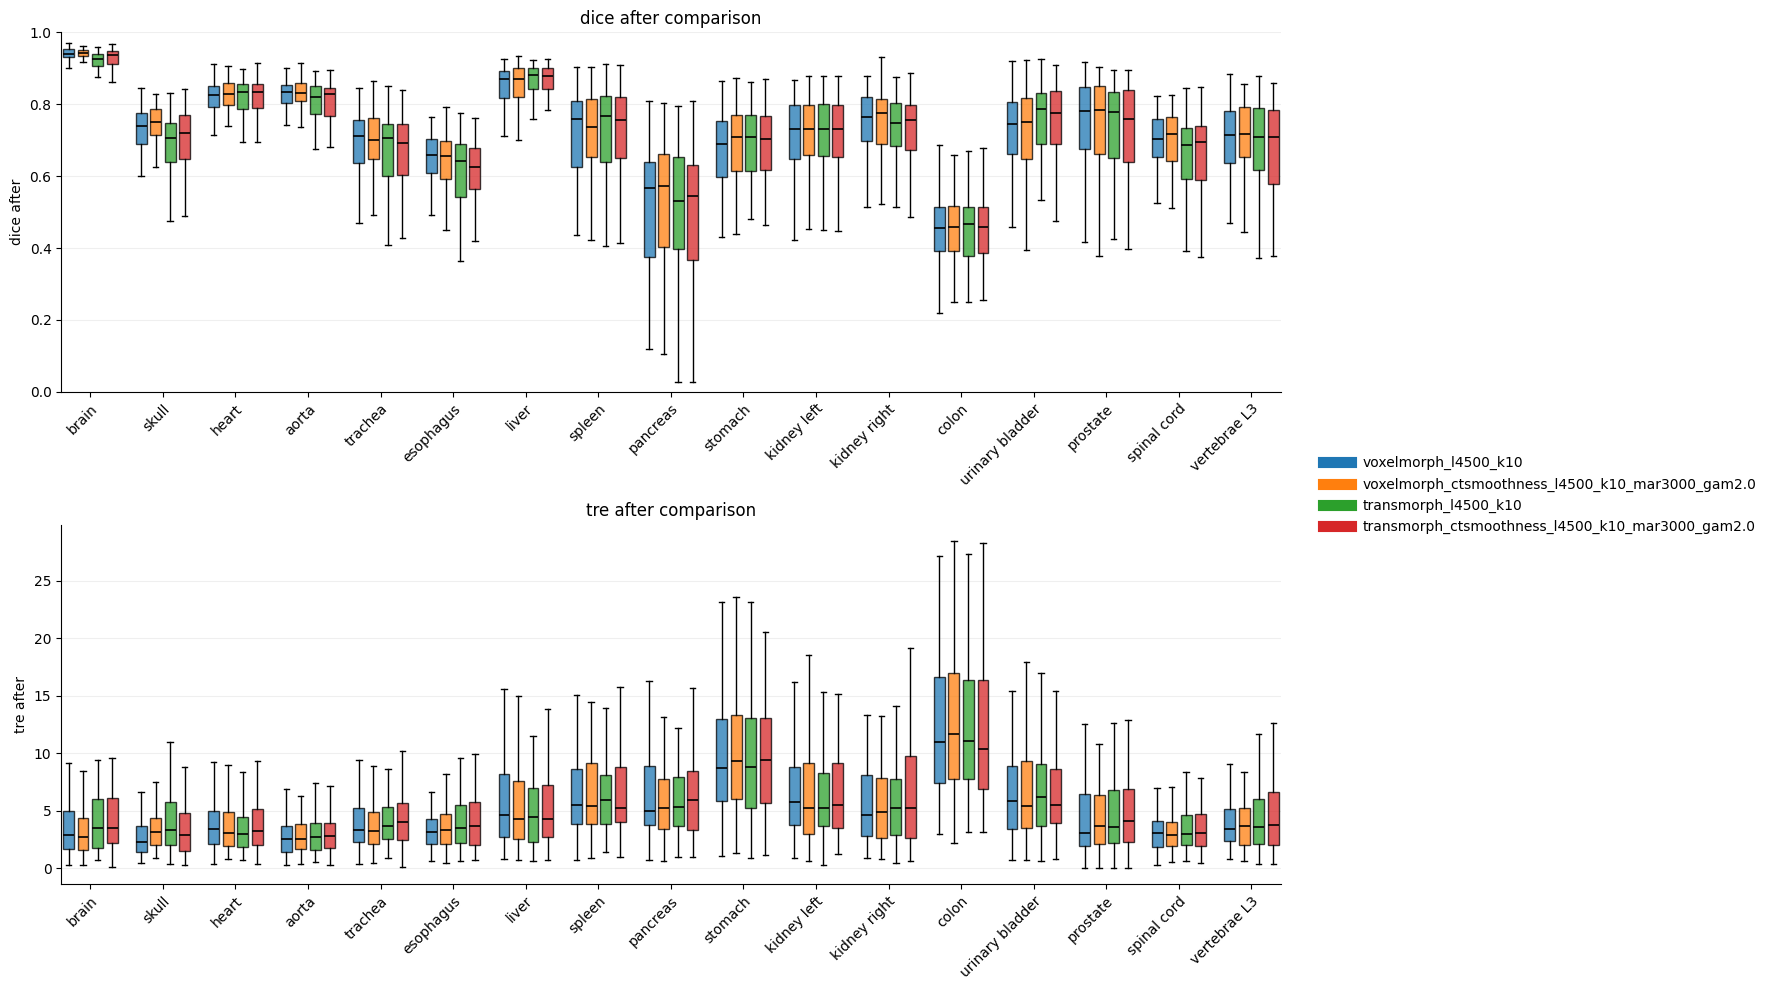

In [24]:
import ast
import os

import matplotlib.pyplot as plt
import numpy as np

DEFAULT_ORGANS = [
    "brain",
    "skull",
    "heart",
    "aorta",
    "trachea",
    "esophagus",
    "liver",
    "spleen",
    "pancreas",
    "stomach",
    "kidney_left",
    "kidney_right",
    "colon",
    "urinary_bladder",
    "prostate",
    "spinal_cord",
    "vertebrae_L3",
]

TXT_FILES = [
    # "/share/home/xcwu/pet_reg_results/ctsmoothness_l4500_k10_mar3000_gam2.0.txt",
    # # "voxelmorph_l7000_k10.txt",
    # # "/share/home/xcwu/pet_reg_results/voxelmorph_l7000_k10.txt",
    # # "/share/home/xcwu/pet_reg_results/voxelmorph_l7000_k10_ctinput.txt",
    # "/share/home/xcwu/pet_reg_results/voxelmorph_ctsmoothness_l4500_k10_mar3000_gam2.0.txt",
    # # "/share/home/xcwu/pet_reg_results/transmorph_l7000_k10.txt",
    # # "/share/home/xcwu/pet_reg_results/transmorph_l7000_k10_ctinput.txt",
    # "/share/home/xcwu/pet_reg_results/transmorph_ctsmoothness_l4500_k10_mar3000_gam2.0.txt",
    # # "/share/home/xcwu/pet_reg_results/ants_fdgct_to_psmact.txt"
    
    
    
    #
    # "/share/home/xcwu/pet_reg_results/baseline_l7000_k10.txt",
    # "/share/home/xcwu/pet_reg_results/ctsmoothness_l7000_k10_mar3000_gam2.0.txt",
    "/share/home/xcwu/pet_reg_results/voxelmorph_l4500_k10.txt",
    "/share/home/xcwu/pet_reg_results/voxelmorph_ctsmoothness_l4500_k10_mar3000_gam2.0.txt",
    "/share/home/xcwu/pet_reg_results/transmorph_l4500_k10.txt",
    "/share/home/xcwu/pet_reg_results/transmorph_ctsmoothness_l4500_k10_mar3000_gam2.0.txt",

    
    
]

LABELS = None

# 单指标绘图时仍可使用 METRIC；main 里默认改为画 Dice + TRE 两行。
METRIC = "dice_after"
METRICS = ["dice_after", "tre_after"]

ORGANS = DEFAULT_ORGANS
USE_HORIZONTAL = False
SHOW_FLIERS = False
TITLE = None
OUTPUT = None


def parse_list_line(line):
    values = []
    for part in line.strip().split(";"):
        part = part.strip()
        try:
            values.append(ast.literal_eval(part))
        except Exception:
            values.append(part)
    return values


def load_registration_results(filename):
    """
    Load one registration result txt produced by Registration/inferencing.py.

    Returns:
        dict with masks_names, dice_before, dice_after, tre_before, tre_after.
    """
    with open(filename, "r") as f:
        lines = f.readlines()

    if len(lines) < 5:
        raise ValueError(
            f"{filename} should contain at least 5 lines: masks, dice before, "
            "dice after, TRE before, TRE after."
        )

    return {
        "masks_names": parse_list_line(lines[0]),
        "dice_before": parse_list_line(lines[1]),
        "dice_after": parse_list_line(lines[2]),
        "tre_before": parse_list_line(lines[3]),
        "tre_after": parse_list_line(lines[4]),
    }


def common_organs(results):
    common = set(results[0]["masks_names"])
    for result in results[1:]:
        common &= set(result["masks_names"])

    return [organ for organ in results[0]["masks_names"] if organ in common]


def choose_organs(results, organs, use_default_organs):
    available = common_organs(results)
    if organs:
        missing = [organ for organ in organs if organ not in available]
        if missing:
            raise ValueError(
                "These organs are missing from at least one txt file: "
                + ", ".join(missing)
            )
        return organs

    if use_default_organs:
        selected = [organ for organ in DEFAULT_ORGANS if organ in available]
        if selected:
            return selected

    return available


def collect_metric_data(results, metric, selected_organs):
    all_data = []
    for result in results:
        masks_names = result["masks_names"]
        metric_lists = result[metric]
        data_for_file = []

        for organ in selected_organs:
            organ_index = masks_names.index(organ)
            data_for_file.append(np.asarray(metric_lists[organ_index], dtype=float))

        all_data.append(data_for_file)

    return all_data


def make_colors(num_items):
    cmap = plt.get_cmap("tab10")
    return [cmap(i % 10) for i in range(num_items)]


def metric_display_name(metric):
    return metric.replace("_", " ")


def average_over_organs(data_for_file):
    """
    先对每个 organ 的所有 case 求平均，再对所有 organ 的平均值求平均。
    这样每个 organ 权重相同，不会因为某个 organ 的 case 更多而权重更大。
    """
    organ_means = []
    for values in data_for_file:
        values = np.asarray(values, dtype=float)
        values = values[~np.isnan(values)]
        if values.size > 0:
            organ_means.append(float(np.mean(values)))

    if not organ_means:
        return np.nan
    return float(np.mean(organ_means))


def compute_metric_averages(results, labels, selected_organs, metric):
    metric_data = collect_metric_data(results, metric, selected_organs)
    return {
        label: average_over_organs(data_for_file)
        for label, data_for_file in zip(labels, metric_data)
    }


def print_metric_averages(results, labels, selected_organs, metrics):
    print("Average over selected organs (mean per organ first, then mean over organs):")
    for metric in metrics:
        averages = compute_metric_averages(results, labels, selected_organs, metric)
        print(f"\n{metric_display_name(metric)}:")
        for label in labels:
            value = averages[label]
            if np.isnan(value):
                print(f"  {label}: nan")
            else:
                print(f"  {label}: {value:.4f}")


def plot_metric_boxplot(
    results,
    labels,
    selected_organs,
    metric="dice_after",
    title=None,
    orientation="vertical",
    show_fliers=False,
    ax=None,
    add_legend=True,
):
    """
    Plot grouped boxplots. Each txt file becomes one boxplot series.
    If ax is provided, draw into that axis. Otherwise create a new figure.
    """
    metric_data = collect_metric_data(results, metric, selected_organs)
    num_organs = len(selected_organs)
    num_files = len(results)

    if num_organs == 0:
        raise ValueError("No organs selected for plotting.")

    colors = make_colors(num_files)
    group_spacing = num_files + 1
    positions_base = np.arange(num_organs) * group_spacing
    box_width = 0.75

    if ax is None:
        if orientation == "horizontal":
            fig, ax = plt.subplots(figsize=(9, max(5, num_organs * 0.45)))
        else:
            fig, ax = plt.subplots(figsize=(max(14, num_organs * 0.9), 6))
    else:
        fig = ax.figure

    for file_index, (data_for_file, label) in enumerate(zip(metric_data, labels)):
        offset = file_index - (num_files - 1) / 2
        positions = positions_base + offset

        boxplot_kwargs = {
            "positions": positions,
            "widths": box_width,
            "patch_artist": True,
            "showfliers": show_fliers,
            "flierprops": {
                "marker": "o",
                "markersize": 3,
                "linestyle": "none",
                "markerfacecolor": "black",
                "alpha": 0.45,
            },
        }
        if orientation == "horizontal":
            boxplot_kwargs["vert"] = False

        bp = ax.boxplot(data_for_file, **boxplot_kwargs)
        for patch in bp["boxes"]:
            patch.set_facecolor(colors[file_index])
            patch.set_alpha(0.75)
        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.2)

        # 用于图例的空线条
        ax.plot([], [], color=colors[file_index], linewidth=8, label=label)

    clean_organs = [organ.replace("_", " ") for organ in selected_organs]
    if orientation == "horizontal":
        ax.set_yticks(positions_base)
        ax.set_yticklabels(clean_organs)
        ax.set_xlabel(metric_display_name(metric))
        if metric.startswith("dice"):
            ax.set_xlim(0, 1)
    else:
        ax.set_xticks(positions_base)
        ax.set_xticklabels(
            clean_organs,
            rotation=45,
            ha="right",
            rotation_mode="anchor",
        )
        ax.set_ylabel(metric_display_name(metric))
        if metric.startswith("dice"):
            ax.set_ylim(0, 1)

    if title:
        ax.set_title(title)

    if add_legend:
        ax.legend(
            ncol=1,
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1, 0.5),
            fontsize="medium",
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x" if orientation == "horizontal" else "y", alpha=0.2)

    if add_legend:
        fig.tight_layout(rect=[0, 0, 0.85, 1])
    return fig, ax


def default_label_from_path(path):
    return os.path.splitext(os.path.basename(path))[0]


def plot_boxplots_from_txt_files(
    txt_files,
    labels=None,
    metric="dice_after",
    organs=None,
    use_horizontal=False,
    show_fliers=False,
    title=None,
    output=None,
    print_average=True,
):
    """
    Backward-compatible single-metric plotting function.
    """
    results = [load_registration_results(path) for path in txt_files]

    if labels is None:
        labels = [default_label_from_path(path) for path in txt_files]
    if len(labels) != len(txt_files):
        raise ValueError("labels must have the same length as txt_files.")

    selected_organs = choose_organs(
        results,
        organs=organs,
        use_default_organs=False,
    )

    if print_average:
        print_metric_averages(results, labels, selected_organs, [metric])

    if title is None:
        title = f"{metric_display_name(metric)} comparison"

    fig, _ = plot_metric_boxplot(
        results,
        labels,
        selected_organs,
        metric=metric,
        title=title,
        orientation="horizontal" if use_horizontal else "vertical",
        show_fliers=show_fliers,
    )

    if output:
        fig.savefig(output, dpi=300, bbox_inches="tight")
        print(f"Saved figure to {output}")

    plt.show()
    return fig


def plot_metrics_boxplots_from_txt_files(
    txt_files,
    labels=None,
    metrics=None,
    organs=None,
    use_horizontal=False,
    show_fliers=False,
    title=None,
    output=None,
    print_averages=True,
):
    """
    Plot multiple metrics in separate rows, e.g. Dice in the first row and TRE in the second row.
    Also print average score for each method over selected organs.
    """
    if metrics is None:
        metrics = ["dice_after", "tre_after"]

    results = [load_registration_results(path) for path in txt_files]

    if labels is None:
        labels = [default_label_from_path(path) for path in txt_files]
    if len(labels) != len(txt_files):
        raise ValueError("labels must have the same length as txt_files.")

    selected_organs = choose_organs(
        results,
        organs=organs,
        use_default_organs=False,
    )

    if print_averages:
        print_metric_averages(results, labels, selected_organs, metrics)

    num_metrics = len(metrics)
    num_organs = len(selected_organs)

    if use_horizontal:
        figsize = (9, max(5, num_organs * 0.45) * num_metrics)
    else:
        figsize = (max(14, num_organs * 0.9), 5 * num_metrics)

    fig, axes = plt.subplots(num_metrics, 1, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    for ax, metric in zip(axes, metrics):
        plot_metric_boxplot(
            results,
            labels,
            selected_organs,
            metric=metric,
            title=f"{metric_display_name(metric)} comparison",
            orientation="horizontal" if use_horizontal else "vertical",
            show_fliers=show_fliers,
            ax=ax,
            add_legend=False,
        )

    handles, legend_labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        legend_labels,
        ncol=1,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(0.86, 0.5),
        fontsize="medium",
    )

    if title:
        fig.suptitle(title)
        fig.tight_layout(rect=[0, 0, 0.85, 0.95])
    else:
        fig.tight_layout(rect=[0, 0, 0.85, 1])

    if output:
        fig.savefig(output, dpi=300, bbox_inches="tight")
        print(f"Saved figure to {output}")

    plt.show()
    return fig


def main():
    if not TXT_FILES:
        raise ValueError("Please fill TXT_FILES with one or more result txt paths.")

    plot_metrics_boxplots_from_txt_files(
        TXT_FILES,
        labels=LABELS,
        metrics=METRICS,
        organs=ORGANS,
        use_horizontal=USE_HORIZONTAL,
        show_fliers=SHOW_FLIERS,
        title=TITLE,
        output=OUTPUT,
        print_averages=True,
    )


if __name__ == "__main__":
    main()
